# MLHW4-4


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

## Task 0: Load Data and Split into X and y

In [30]:
df = pd.read_csv('spam.data', sep=' ', header=None)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4601, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [31]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Spam ratio: {y.mean():.3f}")

X shape: (4601, 57)
y shape: (4601,)
Spam ratio: 0.394


## Task 1: Feature Averages Conditional on Spam Status

In [32]:
avg_non_spam = X[y == 0].mean()
avg_spam = X[y == 1].mean()

comparison_df = pd.DataFrame({
    'Non-Spam Average': avg_non_spam,
    'Spam Average': avg_spam,
    'Difference': avg_spam - avg_non_spam
})

print("Feature averages by class:")
comparison_df.head(10)

Feature averages by class:


,Non-Spam Average,Spam Average,Difference
0,0.073479,0.152339,0.078859
1,0.244466,0.164650,-0.079816
2,0.200581,0.403795,0.203214
3,0.000886,0.164672,0.163786
4,0.181040,0.513955,0.332915
5,0.044544,0.174876,0.130331
6,0.009383,0.275405,0.266022
7,0.038415,0.208141,0.169727
8,0.038049,0.170061,0.132012
9,0.167170,0.350507,0.183337


## Task 2: Standardize and Split Data

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")
print(f"Training spam ratio: {y_train.mean():.3f}")
print(f"Test spam ratio: {y_test.mean():.3f}")

Training set: (3680, 57), Test set: (921, 57)
Training spam ratio: 0.394
Test spam ratio: 0.394


## Task 3: XGBoost with Hyperparameter Tuning

In [34]:
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda': [0, 1, 10],
    'reg_alpha': [0, 0.5, 1]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)
print("GridSearchCV completed.")

Starting GridSearchCV...
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
GridSearchCV completed.


## Task 4: Cross-Validation Results

In [35]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score')

print("Top 10 cross-validation results:")
cv_results_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)

Top 10 cross-validation results:


,params,mean_test_score,std_test_score,rank_test_score
458,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.958696,0.009515,1
137,"{'colsample_bytree': 0.7, 'learning_rate': 0.1...",0.958152,0.011217,2
485,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.957880,0.010419,3
221,"{'colsample_bytree': 0.7, 'learning_rate': 0.3...",0.957880,0.011204,4
110,"{'colsample_bytree': 0.7, 'learning_rate': 0.1...",0.957880,0.011593,4
194,"{'colsample_bytree': 0.7, 'learning_rate': 0.3...",0.957609,0.011051,6
170,"{'colsample_bytree': 0.7, 'learning_rate': 0.3...",0.957609,0.008696,6
416,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.957337,0.011738,8
398,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.957337,0.010043,8
443,"{'colsample_bytree': 0.8, 'learning_rate': 0.3...",0.957065,0.011289,10


In [36]:
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best cross-validation score: 0.9587


### Interpretation of Cross-Validation Results

**Best Performance:** The model achieved a mean cross-validation accuracy of **95.87%** with low variance.
**Robustness:** Scores are highly consistent across the top parameter sets, indicating the model is stable and not overly sensitive to minor hyperparameter changes.

## Task 5: Best Model Selection

In [37]:
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best model parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

Best model parameters:
  colsample_bytree: 0.8
  learning_rate: 0.3
  n_estimators: 200
  reg_alpha: 1
  reg_lambda: 10
  subsample: 1.0


### Interpretation of Best Model

**Key Hyperparameters:** 
- `n_estimators=200`, `learning_rate=0.3` (Balance of speed and capacity)
- `reg_alpha=1`, `reg_lambda=10` (Strong L1/L2 regularization)
- `colsample_bytree=0.8` (Feature subsampling)

**Takeaway:** The model utilizes **strong regularization** and **feature diversity** to prevent overfitting while maintaining high predictive power on this structured dataset.

## Task 6: Test Set Evaluation

In [38]:
y_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Spam', 'Spam']))

Test Set Accuracy: 0.9511

Classification Report:
              precision    recall  f1-score   support

    Non-Spam       0.96      0.96      0.96       558
        Spam       0.94      0.94      0.94       363

    accuracy                           0.95       921
   macro avg       0.95      0.95      0.95       921
weighted avg       0.95      0.95      0.95       921



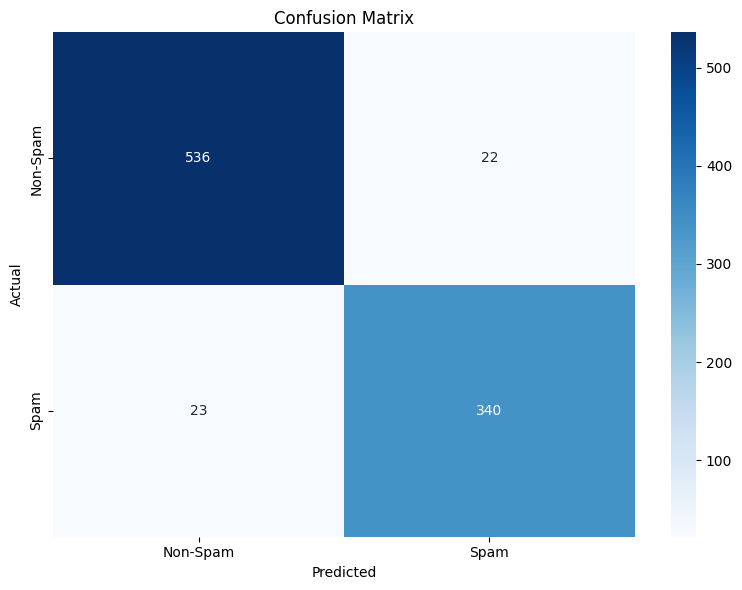

In [39]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Spam', 'Spam'], yticklabels=['Non-Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Interpretation of Test Performance

**Accuracy:** **95.11%** on the test set, aligning closely with CV results (95.87%).
**Error Profile:**
- **Symmetric Errors:** 22 False Positives vs 23 False Negatives.
- **Balanced Class Metrics:** Precision and Recall > 0.94 for both Spam and Non-Spam.
- **Conclusion:** Excellent generalization with no bias toward either class.

## Task 7: Feature Visualization with PCA

In [40]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

PCA explained variance ratio: [0.07625762 0.06200263]
Total variance explained: 0.1383


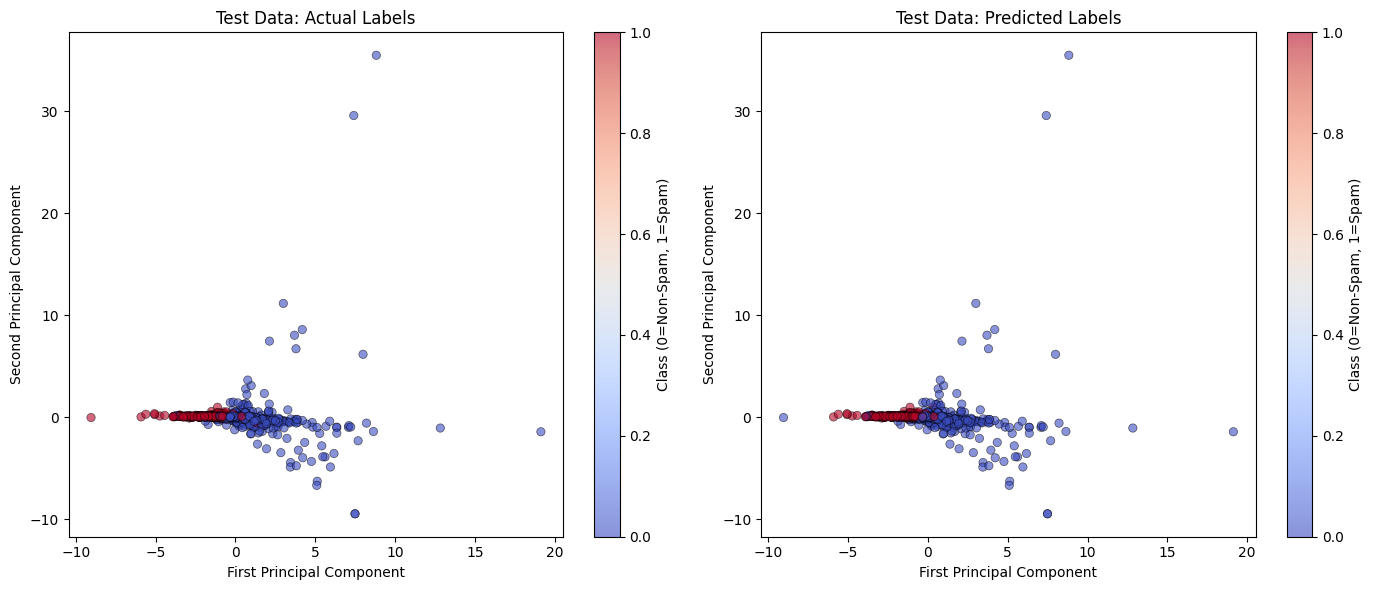

In [41]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Test Data: Actual Labels')
plt.colorbar(scatter1, label='Class (0=Non-Spam, 1=Spam)')

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='coolwarm', alpha=0.6, edgecolors='k', linewidth=0.5)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Test Data: Predicted Labels')
plt.colorbar(scatter2, label='Class (0=Non-Spam, 1=Spam)')

plt.tight_layout()
plt.show()

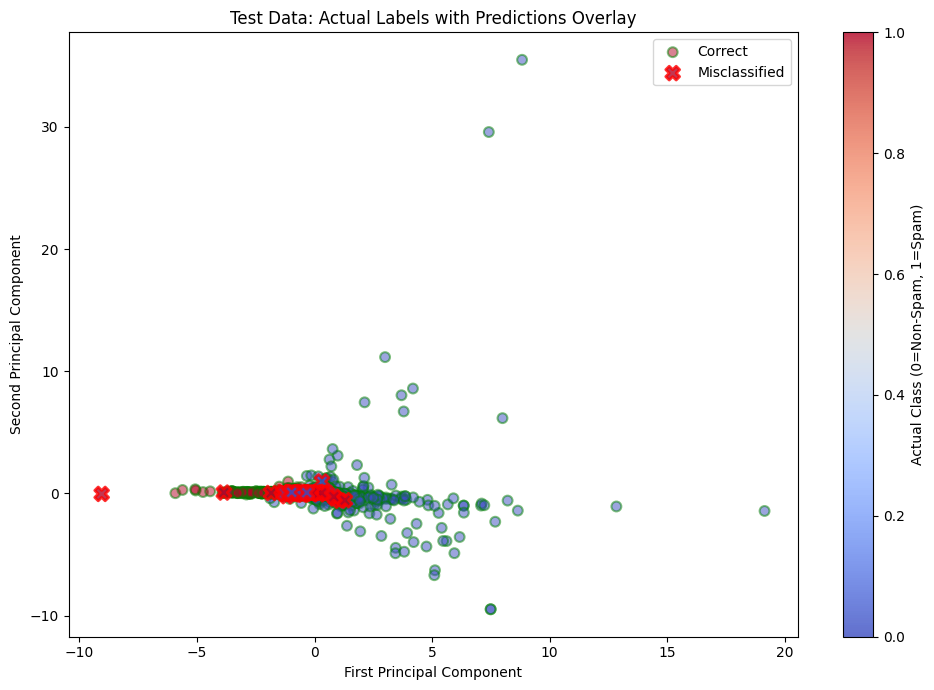

In [42]:
correct = y_test == y_pred
plt.figure(figsize=(10, 7))
plt.scatter(X_test_pca[correct, 0], X_test_pca[correct, 1], c=y_test[correct], cmap='coolwarm', alpha=0.5, edgecolors='g', linewidth=1.5, s=50, label='Correct')
plt.scatter(X_test_pca[~correct, 0], X_test_pca[~correct, 1], c=y_test[~correct], cmap='coolwarm', alpha=0.8, edgecolors='r', linewidth=2, s=100, marker='X', label='Misclassified')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Test Data: Actual Labels with Predictions Overlay')
plt.legend()
plt.colorbar(label='Actual Class (0=Non-Spam, 1=Spam)')
plt.tight_layout()
plt.show()

### Interpretation of Visualization

**PCA Limit:** 2D projection explains only **13.83%** of variance but shows partial class separation.
**Error Analysis:** Misclassifications (red Xs) cluster in the **central overlap region** where feature patterns are ambiguous in 2D.
**Conclusion:** Linear separation in 2D is limited; the model's 95% accuracy relies on decision boundaries in the full 57-dimensional space.